# CNN Inference vs. Charge Barycenter — BFM Cross-check

Compares two independent vertex reconstruction methods on **real SBND data**:

| Method | Description |
|--------|-------------|
| **Charge Barycenter** | Energy-weighted centroid of TPC space-points (reference) |
| **Flash Barycenter (BFM)** | PMT flash centroid matched to the TPC charge cluster |
| **CNN (ResNet)** | Predicted neutrino barycenter and direction from the optical image |

**Strategy:** select beam-matched BFM entries (score, nuScore, flash time), merge with CNN inference by `(run, event)`, then compare position and direction residuals.

---

In [1]:
import sys
sys.path.insert(0, '/exp/sbnd/app/users/svidales/larsoft_develop/srcs/sbndcode/sbndcode/NuIntNNOpReco/2-cnn-training-notebooks/')
from plot_style import *

import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from scipy.optimize import curve_fit
from scipy import stats

%matplotlib inline
pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:
from datetime import datetime
import os

# Output directory with timestamp
_ts = datetime.now().strftime("%Y%m%d_%H%M%S")
FIG_DIR = f"/exp/sbnd/data/users/svidales/AI_nuvT_project_support/AA_Final_Wrapup/position_DATA/BFM/figures_{_ts}"
os.makedirs(FIG_DIR, exist_ok=True)
print(f"Figures will be saved to: {FIG_DIR}")

Figures will be saved to: /exp/sbnd/data/users/svidales/AI_nuvT_project_support/AA_Final_Wrapup/position_DATA/BFM/figures_20260427_140623


## 1. Load Data

### 1.1 BFM Matching File

Tree `tpcpmtbarycentermatchingSCE/matchTree` — one row per TPC-PMT matched pair.  
Contains charge barycenter, flash centroid, BFM score, nuScore, flash time, and PCA direction.

In [3]:
#file = uproot.open("/exp/sbnd/data/users/svidales/AI_nuvT_project_support/AA_Final_Wrapup/position_DATA/BFM/tpcpmtmatching/join_40000/join_40000.root")
file = uproot.open("/exp/sbnd/data/users/svidales/AI_nuvT_project_support/AA_Final_Wrapup/position_DATA/BFM/tpcpmtmatching/merged_grid/merged_grid_v2404_bfm.root")

tree = file['tpcpmtbarycentermatchingSCE/matchTree;1']
print(f"Entries: {tree.num_entries}")

Entries: 6887830


### 1.2 CNN Inference File

Tree `ResNetInference/inference_tree` — one row per event passing the module filters.  
Contains predicted position `(pred_x, pred_y, pred_z)`, direction `(pred_dir_y, pred_dir_z)`, and the selected TPC.

In [4]:
#file2 = uproot.open("/exp/sbnd/data/users/svidales/AI_nuvT_project_support/AA_Final_Wrapup/position_DATA/BFM/resnet_inference/join_40000/join_40000_resnet.root")
file2 = uproot.open("/exp/sbnd/data/users/svidales/AI_nuvT_project_support/AA_Final_Wrapup/position_DATA/BFM/resnet_inference/merged_grid/merged_grid_v2404_resnet.root")

tree2 = file2['ResNetInference/inference_tree']
n_total_events = tree2.num_entries
print(f"Entries: {n_total_events}")

df_inference = tree2.arrays(library='pd')
n_total_inf = len(df_inference)
df_inference = df_inference[df_inference['passed_filters'] == True].reset_index(drop=True)
print(f"Inference events passing filters: {len(df_inference)} / {n_total_inf} ({100*len(df_inference)/n_total_inf:.1f}%)")
df_inference = df_inference.drop(columns=['subrun', 'passed_filters'])
print(f"Columns: {list(df_inference.columns)}")
df_inference.head()

Entries: 242023
Inference events passing filters: 222076 / 242023 (91.8%)
Columns: ['run', 'event', 'pred_x', 'pred_y', 'pred_z', 'selected_tpc', 'pred_dir_y', 'pred_dir_z']


,run,event,pred_x,pred_y,pred_z,selected_tpc,pred_dir_y,pred_dir_z
0,18253,483289,124.95,-182.46,364.94,0,-0.18,0.98
1,18253,483619,62.62,193.96,461.80,0,0.49,0.87
2,18253,483861,149.22,-28.82,333.83,1,0.29,0.96
3,18253,484147,161.57,-192.79,104.59,0,-0.13,0.99
4,18253,484191,121.16,-85.33,194.28,0,0.61,0.80


In [5]:
# Load BFM data and remove unnecessary columns
df = tree.arrays(library='pd')

columns_to_remove = [
    'deltaZ_Trigger', 'deltaY_Trigger', 'radius_Trigger',  # Trigger metrics
    'chargeWidthX', 'chargeWidthY', 'chargeWidthZ',        # Charge widths
    'flashWidthY', 'flashWidthZ',                          # Flash widths
    'chargeT0', 'deltaT'                                   # Always -9999
]

df = df.drop(columns=columns_to_remove)

print(f"Columns: {len(df.columns)} | Unique events: {df['event'].nunique()} | Unique runs: {df['run'].nunique()}")

Columns: 20 | Unique events: 205195 | Unique runs: 19


### 1.3 Flash Time Exploration

Check the flash time distribution to confirm the beam window and quantify beam-in-time fraction before applying cuts.

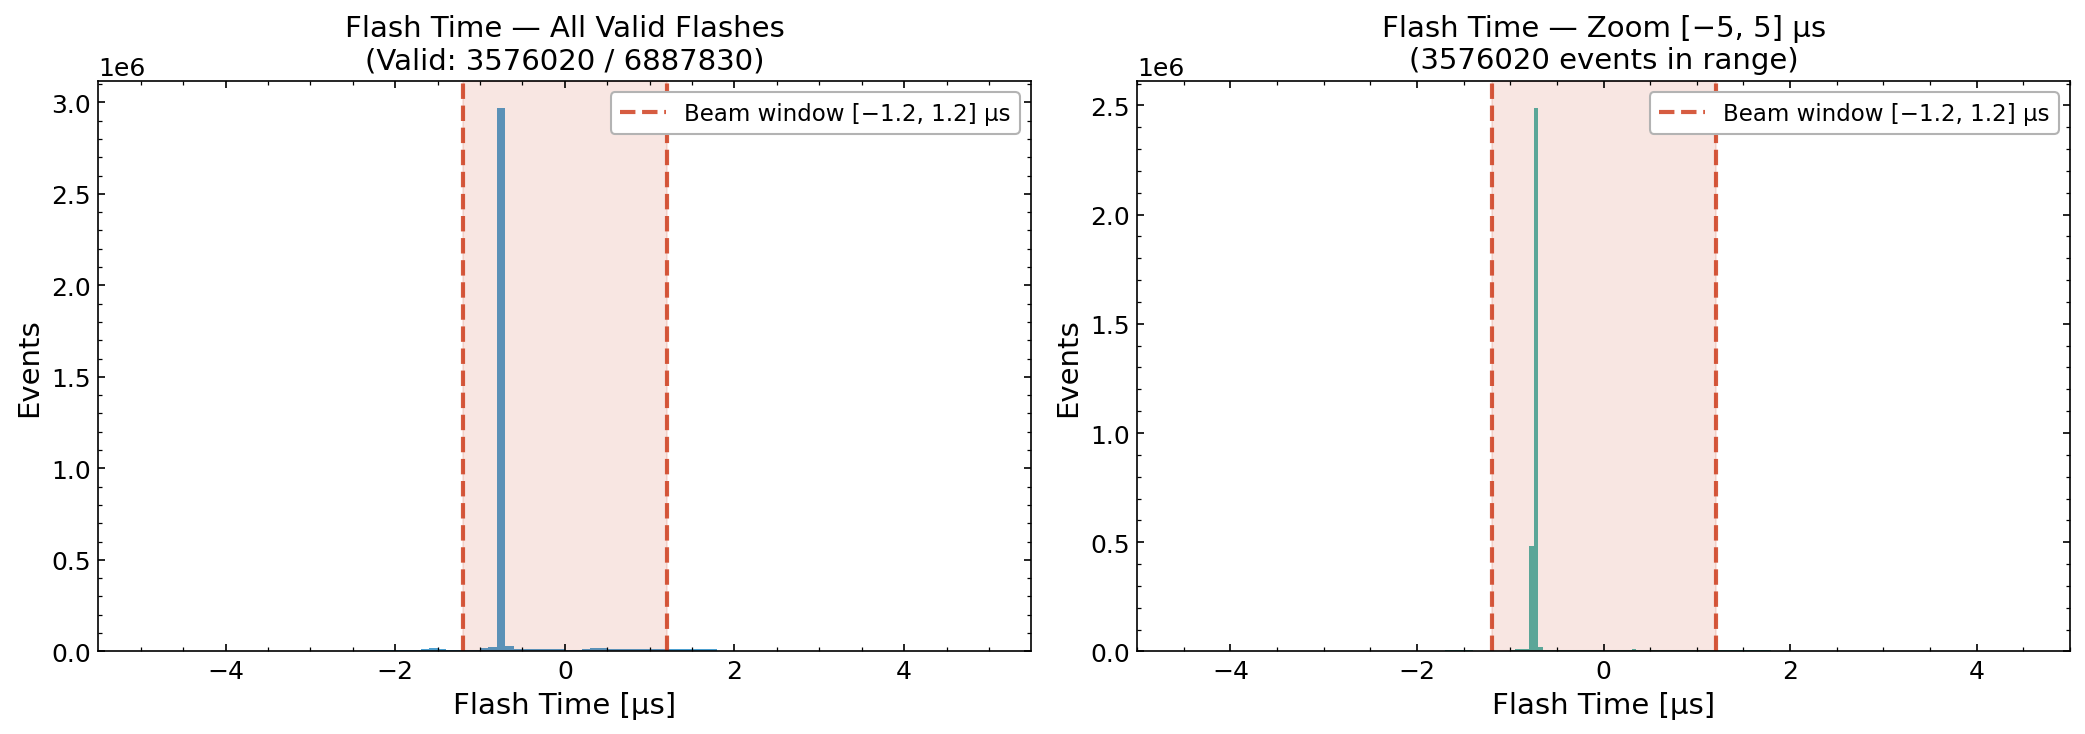

                         FLASH TIME STATISTICS

Total entries:                6887830
Valid flashes:                3576020 (51.9%)
Invalid entries:              3311810 (48.1%)

Statistic                                Value
--------------------------------------------------------------------------------
Mean                                     -0.60 μs
Std                                       0.81 μs
Median                                   -0.74 μs
Min                                      -5.00 μs
Max                                       5.00 μs

Window                                   Count      Percentage
--------------------------------------------------------------------------------
In beam window [-1.2, 1.2]             3284893           91.9%
In old window [-2, 2]                  3439749           96.2%
In zoom region [-5, 5]                 3576020          100.0%
Outside beam window                     291127            8.1%

Region around beam window                Coun

In [6]:
# Flash time analysis
from matplotlib.ticker import AutoMinorLocator

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

flash_times = df['flashTime']
flash_times_valid = flash_times[(flash_times != -9999) & (flash_times != -10000)]

ax = axes[0]
ax.hist(flash_times_valid, bins=100, alpha=0.7, color=C_PRIMARY, edgecolor='none')
ax.set_xlabel('Flash Time [μs]', fontsize=FONT_LABEL)
ax.set_ylabel('Events', fontsize=FONT_LABEL)
ax.set_title(f'Flash Time — All Valid Flashes\n(Valid: {len(flash_times_valid)} / {len(flash_times)})', fontweight='normal')
ax.tick_params(labelsize=FONT_TICK)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.axvline(-1.2, color=C_ALERT, linestyle='--', linewidth=2, label='Beam window [−1.2, 1.2] μs', alpha=0.8)
ax.axvline( 1.2, color=C_ALERT, linestyle='--', linewidth=2, alpha=0.8)
ax.axvspan(-1.2, 1.2, alpha=0.12, color=C_ALERT)
ax.legend(fontsize=FONT_STAT)

ax = axes[1]
flash_times_zoom = flash_times_valid[(flash_times_valid >= -5) & (flash_times_valid <= 5)]
ax.hist(flash_times_zoom, bins=200, alpha=0.7, color=C_TERTIARY, edgecolor='none')
ax.set_xlabel('Flash Time [μs]', fontsize=FONT_LABEL)
ax.set_ylabel('Events', fontsize=FONT_LABEL)
ax.set_title(f'Flash Time — Zoom [−5, 5] μs\n({len(flash_times_zoom)} events in range)', fontweight='normal')
ax.set_xlim(-5, 5)
ax.tick_params(labelsize=FONT_TICK)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.axvline(-1.2, color=C_ALERT, linestyle='--', linewidth=2, label='Beam window [−1.2, 1.2] μs', alpha=0.8)
ax.axvline( 1.2, color=C_ALERT, linestyle='--', linewidth=2, alpha=0.8)
ax.axvspan(-1.2, 1.2, alpha=0.12, color=C_ALERT)
ax.legend(fontsize=FONT_STAT)

plt.tight_layout()
fig.savefig(f"{FIG_DIR}/flash_time_distribution.png", dpi=SAVE_DPI, bbox_inches='tight')
fig.savefig(f"{FIG_DIR}/flash_time_distribution.pdf", bbox_inches='tight')
plt.show()

print("="*80)
print(" "*25 + "FLASH TIME STATISTICS")
print("="*80)
print(f"\nTotal entries:                {len(flash_times)}")
print(f"Valid flashes:                {len(flash_times_valid)} ({100*len(flash_times_valid)/len(flash_times):.1f}%)")
print(f"Invalid entries:              {len(flash_times) - len(flash_times_valid)} ({100*(len(flash_times) - len(flash_times_valid))/len(flash_times):.1f}%)")

print(f"\n{'Statistic':30s} {'Value':>15s}")
print("-"*80)
print(f"{'Mean':30s} {flash_times_valid.mean():>15.2f} μs")
print(f"{'Std':30s} {flash_times_valid.std():>15.2f} μs")
print(f"{'Median':30s} {flash_times_valid.median():>15.2f} μs")
print(f"{'Min':30s} {flash_times_valid.min():>15.2f} μs")
print(f"{'Max':30s} {flash_times_valid.max():>15.2f} μs")

in_beam_window = ((flash_times_valid >= -1.2) & (flash_times_valid <= 1.2)).sum()
in_old_window  = ((flash_times_valid >= -2.0) & (flash_times_valid <= 2.0)).sum()
in_zoom_region = ((flash_times_valid >= -5.0) & (flash_times_valid <= 5.0)).sum()
outside_beam   = len(flash_times_valid) - in_beam_window

print(f"\n{'Window':30s} {'Count':>15s} {'Percentage':>15s}")
print("-"*80)
print(f"{'In beam window [-1.2, 1.2]':30s} {in_beam_window:>15d} {100*in_beam_window/len(flash_times_valid):>14.1f}%")
print(f"{'In old window [-2, 2]':30s} {in_old_window:>15d} {100*in_old_window/len(flash_times_valid):>14.1f}%")
print(f"{'In zoom region [-5, 5]':30s} {in_zoom_region:>15d} {100*in_zoom_region/len(flash_times_valid):>14.1f}%")
print(f"{'Outside beam window':30s} {outside_beam:>15d} {100*outside_beam/len(flash_times_valid):>14.1f}%")

print(f"\n{'Region around beam window':30s} {'Count':>15s} {'Percentage':>15s}")
print("-"*80)
regions = [
    ("< -5 μs",              (flash_times_valid < -5)),
    ("[-5, -1.2) μs",        (flash_times_valid >= -5) & (flash_times_valid < -1.2)),
    ("[-1.2, 1.2] μs (BEAM)",(flash_times_valid >= -1.2) & (flash_times_valid <= 1.2)),
    ("(1.2, 5] μs",          (flash_times_valid > 1.2) & (flash_times_valid <= 5)),
    ("> 5 μs",               (flash_times_valid > 5)),
]
for name, mask in regions:
    count = mask.sum()
    print(f"{name:30s} {count:>15d} {100*count/len(flash_times_valid):>14.1f}%")
print("="*80)

## 2. Event Selection — BFM Quality Cuts

Three sequential cuts are applied to select clean beam-neutrino candidates:

| Cut | Variable | Threshold | Purpose |
|-----|----------|-----------|---------|
| BFM match quality | `score` | > 0.1 | Reject poor TPC–PMT associations |
| Pandora neutrino score | `nuScore` | > 0.5 | Reject cosmic-like topologies |
| Beam flash time | `flashTime` | (−1.2, 1.2) μs | Keep only beam-coincident flashes |

In [7]:
score_min   = 0.1
nuScore_min = 0.5
beam_window = (-1.2, 1.2)  # us

n_bfm = len(df)
n_score   = (df['score']   > score_min).sum()
n_nuscore = ((df['score']  > score_min) & (df['nuScore'] > nuScore_min)).sum()

df_cut = df[
    (df['score']     > score_min) &
    (df['nuScore']   > nuScore_min) &
    (df['flashTime'] > beam_window[0]) &
    (df['flashTime'] < beam_window[1])
]
n_cut = len(df_cut)

print('=' * 62)
print('CUT FLOW — BFM selection')
print('=' * 62)
print(f'  score > {score_min},  nuScore > {nuScore_min},  beam: {beam_window} us')
print('-' * 62)
print(f'  Total BFM entries:         {n_bfm:6d}')
print(f'  After score > {score_min}:        {n_score:6d}  ({100*n_score/n_bfm:.1f}%)')
print(f'  After nuScore > {nuScore_min}:     {n_nuscore:6d}  ({100*n_nuscore/n_bfm:.1f}%)')
print(f'  After beam window:         {n_cut:6d}  ({100*n_cut/n_bfm:.1f}%)')
print('=' * 62)

CUT FLOW — BFM selection
  score > 0.1,  nuScore > 0.5,  beam: (-1.2, 1.2) us
--------------------------------------------------------------
  Total BFM entries:         6887830
  After score > 0.1:        143020  (2.1%)
  After nuScore > 0.5:      71427  (1.0%)
  After beam window:          69498  (1.0%)


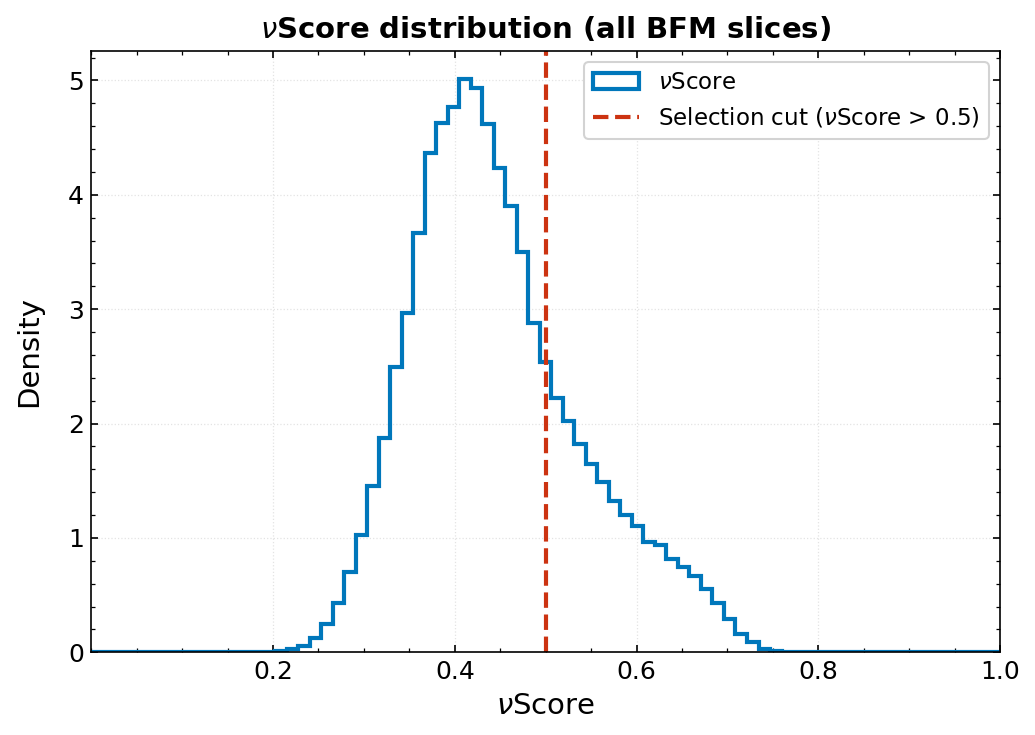

In [19]:
fig, ax = plt.subplots(figsize=(7, 5))

bins = np.linspace(0, 1, 80)

ax.hist(
    df['nuScore'],
    bins=bins,
    density=True,
    histtype='step',
    linewidth=2.0,
    color=C_PRIMARY,
    label=r'$\nu$Score'
)

ax.axvline(
    nuScore_min,
    color=C_ALERT,
    linestyle='--',
    linewidth=2,
    label=fr'Selection cut ($\nu$Score > {nuScore_min})'
)

ax.set_xlabel(r'$\nu$Score', fontsize=FONT_LABEL, fontfamily='DejaVu Sans')
ax.set_ylabel('Density', fontsize=FONT_LABEL, fontfamily='DejaVu Sans', labelpad=12)
ax.set_title(
    r'$\nu$Score distribution (all BFM slices)',
    fontsize=FONT_LABEL,
    fontfamily='DejaVu Sans'
)

ax.set_xlim(0, 1)
ax.tick_params(labelsize=FONT_TICK, direction='in', top=True, right=True, which='both')
ax.grid(True, linestyle=':', alpha=0.35)

# Remove 0.0 tick from x-axis to match the requested presentation.
xt = [t for t in ax.get_xticks() if 0 <= t <= 1 and abs(t) > 1e-9]
ax.set_xticks(xt)

ax.legend(
    fontsize=FONT_STAT,
    frameon=True,
    loc='upper right',
    framealpha=1,
    edgecolor='lightgrey',
    prop={'family': 'DejaVu Sans', 'size': FONT_STAT}
)

plt.tight_layout()
fig.savefig(f"{FIG_DIR}/nuscore_distribution.png", dpi=SAVE_DPI, bbox_inches='tight')
fig.savefig(f"{FIG_DIR}/nuscore_distribution.pdf", bbox_inches='tight')
plt.show()

## 3. Merge BFM Selection with CNN Inference

Join on `(run, event)`. Two additional filters are applied after the merge:

1. **Multi-slice removal** — events where BFM produced more than one matched entry are discarded (ambiguous assignment).
2. **TPC agreement** — events where BFM `cryo` and CNN `selected_tpc` disagree are removed (the two methods selected different drift volumes).

In [9]:
# Merge df_cut with df_inference using run and event
df_comparison = df_cut.merge(
    df_inference[['run', 'event', 'pred_x', 'pred_y', 'pred_z', 'selected_tpc', 'pred_dir_y', 'pred_dir_z']],
    on=['run', 'event'],
    how='left'
)

n_after_merge = len(df_comparison)
print(f"Total entries (rows): {n_after_merge}")
initial_unique_events = df_comparison['event'].nunique()
print(f"Unique events: {initial_unique_events}")

# FIRST FILTER: Count how many events have multiple slices
event_counts = df_comparison.groupby(['run', 'event']).size()
events_multiple = event_counts[event_counts > 1]

if len(events_multiple) > 0:
    events_to_remove = events_multiple.index.tolist()
    mask = df_comparison.apply(lambda row: (row['run'], row['event']) not in events_to_remove, axis=1)
    df_comparison = df_comparison[mask]
    print(f"  Multi-slice events removed: {len(events_multiple)} ({100*len(events_multiple)/initial_unique_events:.1f}%)")
else:
    print("  No multi-slice events")

n_after_dedup = len(df_comparison)

# Apply absolute value to X coordinates (for fair comparison with CNN)
df_comparison['chargeCenterX_abs'] = df_comparison['chargeCenterXGlobal'].abs()
df_comparison['flashCenterX_abs'] = df_comparison['flashCenterX'].abs()

Total entries (rows): 69498
Unique events: 60600
  Multi-slice events removed: 6227 (10.3%)


In [10]:
# Second filter: Remove events where cryo != selected_tpc
# (where BFM and CNN disagree on TPC assignment)

print("="*80)
print(" "*15 + "SECOND FILTER: BFM-CNN TPC AGREEMENT")
print("="*80)

# Count events before filter
events_before = len(df_comparison)
print(f"\nEvents before filter: {events_before}")

# Identify events where cryo != selected_tpc
mismatch_tpc = df_comparison['cryo'] != df_comparison['selected_tpc']
mismatch_events = mismatch_tpc.sum()

print(f"Events where cryo ≠ selected_tpc: {mismatch_events} ({mismatch_events/events_before*100:.1f}%)")
print(f"Events where cryo = selected_tpc: {events_before - mismatch_events} ({(events_before - mismatch_events)/events_before*100:.1f}%)")

# Show some examples of mismatch events
if mismatch_events > 0:
    print(f"\nExamples of mismatch events (first 5):")
    print("-"*80)
    df_mismatch = df_comparison[mismatch_tpc].head()
    print(df_mismatch[['run', 'event', 'cryo', 'selected_tpc', 'score', 'nuScore']].to_string(index=False))

# Apply filter: keep only events where cryo == selected_tpc
df_comparison_filtered = df_comparison[df_comparison['cryo'] == df_comparison['selected_tpc']].copy()

removed_percentage = 100 * mismatch_events / events_before

print(f"\n" + "-"*80)
print(f"AFTER FILTER:")
print(f"  Events remaining: {len(df_comparison_filtered)}")
print(f"  Events removed: {mismatch_events} ({removed_percentage:.1f}%)")
print("="*80)

# Update df_valid with filtered data
df_valid = df_comparison_filtered

               SECOND FILTER: BFM-CNN TPC AGREEMENT

Events before filter: 57040
Events where cryo ≠ selected_tpc: 3749 (6.6%)
Events where cryo = selected_tpc: 53291 (93.4%)

Examples of mismatch events (first 5):
--------------------------------------------------------------------------------
  run  event  cryo  selected_tpc  score  nuScore
18253 500063     1           NaN   0.12     0.57
18253 502989     1           NaN   0.36     0.52
18253 503539     0           NaN   0.28     0.50
18253 485600     1           NaN   0.14     0.63
18253 487668     1           NaN   0.52     0.56

--------------------------------------------------------------------------------
AFTER FILTER:
  Events remaining: 53291
  Events removed: 3749 (6.6%)


In [11]:
# Full cut flow summary
print('=' * 62)
print('FULL CUT FLOW SUMMARY')
print('=' * 62)
print(f'  BFM total entries:              {n_bfm:6d}')
print(f'  After BFM quality cuts:         {n_cut:6d}  ({100*n_cut/n_bfm:.1f}%)')
print(f'  After merge with inference:     {n_after_merge:6d}  ({100*n_after_merge/n_bfm:.1f}%)')
print(f'  After removing multi-slice:     {n_after_dedup:6d}  ({100*n_after_dedup/n_bfm:.1f}%)')
print(f'  After TPC agreement (df_valid): {len(df_valid):6d}  ({100*len(df_valid)/n_bfm:.1f}%)')
print('-' * 62)
print(f'  df_valid vs inference total:    {len(df_valid):6d} / {n_total_events:6d}  ({100*len(df_valid)/n_total_events:.1f}%)')
print('=' * 62)

FULL CUT FLOW SUMMARY
  BFM total entries:              6887830
  After BFM quality cuts:          69498  (1.0%)
  After merge with inference:      69498  (1.0%)
  After removing multi-slice:      57040  (0.8%)
  After TPC agreement (df_valid):  53291  (0.8%)
--------------------------------------------------------------
  df_valid vs inference total:     53291 / 242023  (22.0%)


## 4. Spatial Comparison

### 4.1 Event Displays — Random Sample

Scatter plots of the three reconstruction methods for 10 randomly selected events, shown in the XY, XZ, and YZ projections. Lines connect Charge Barycenter → Flash Center (red) and Charge Barycenter → CNN Prediction (teal) to visualise per-event discrepancies.

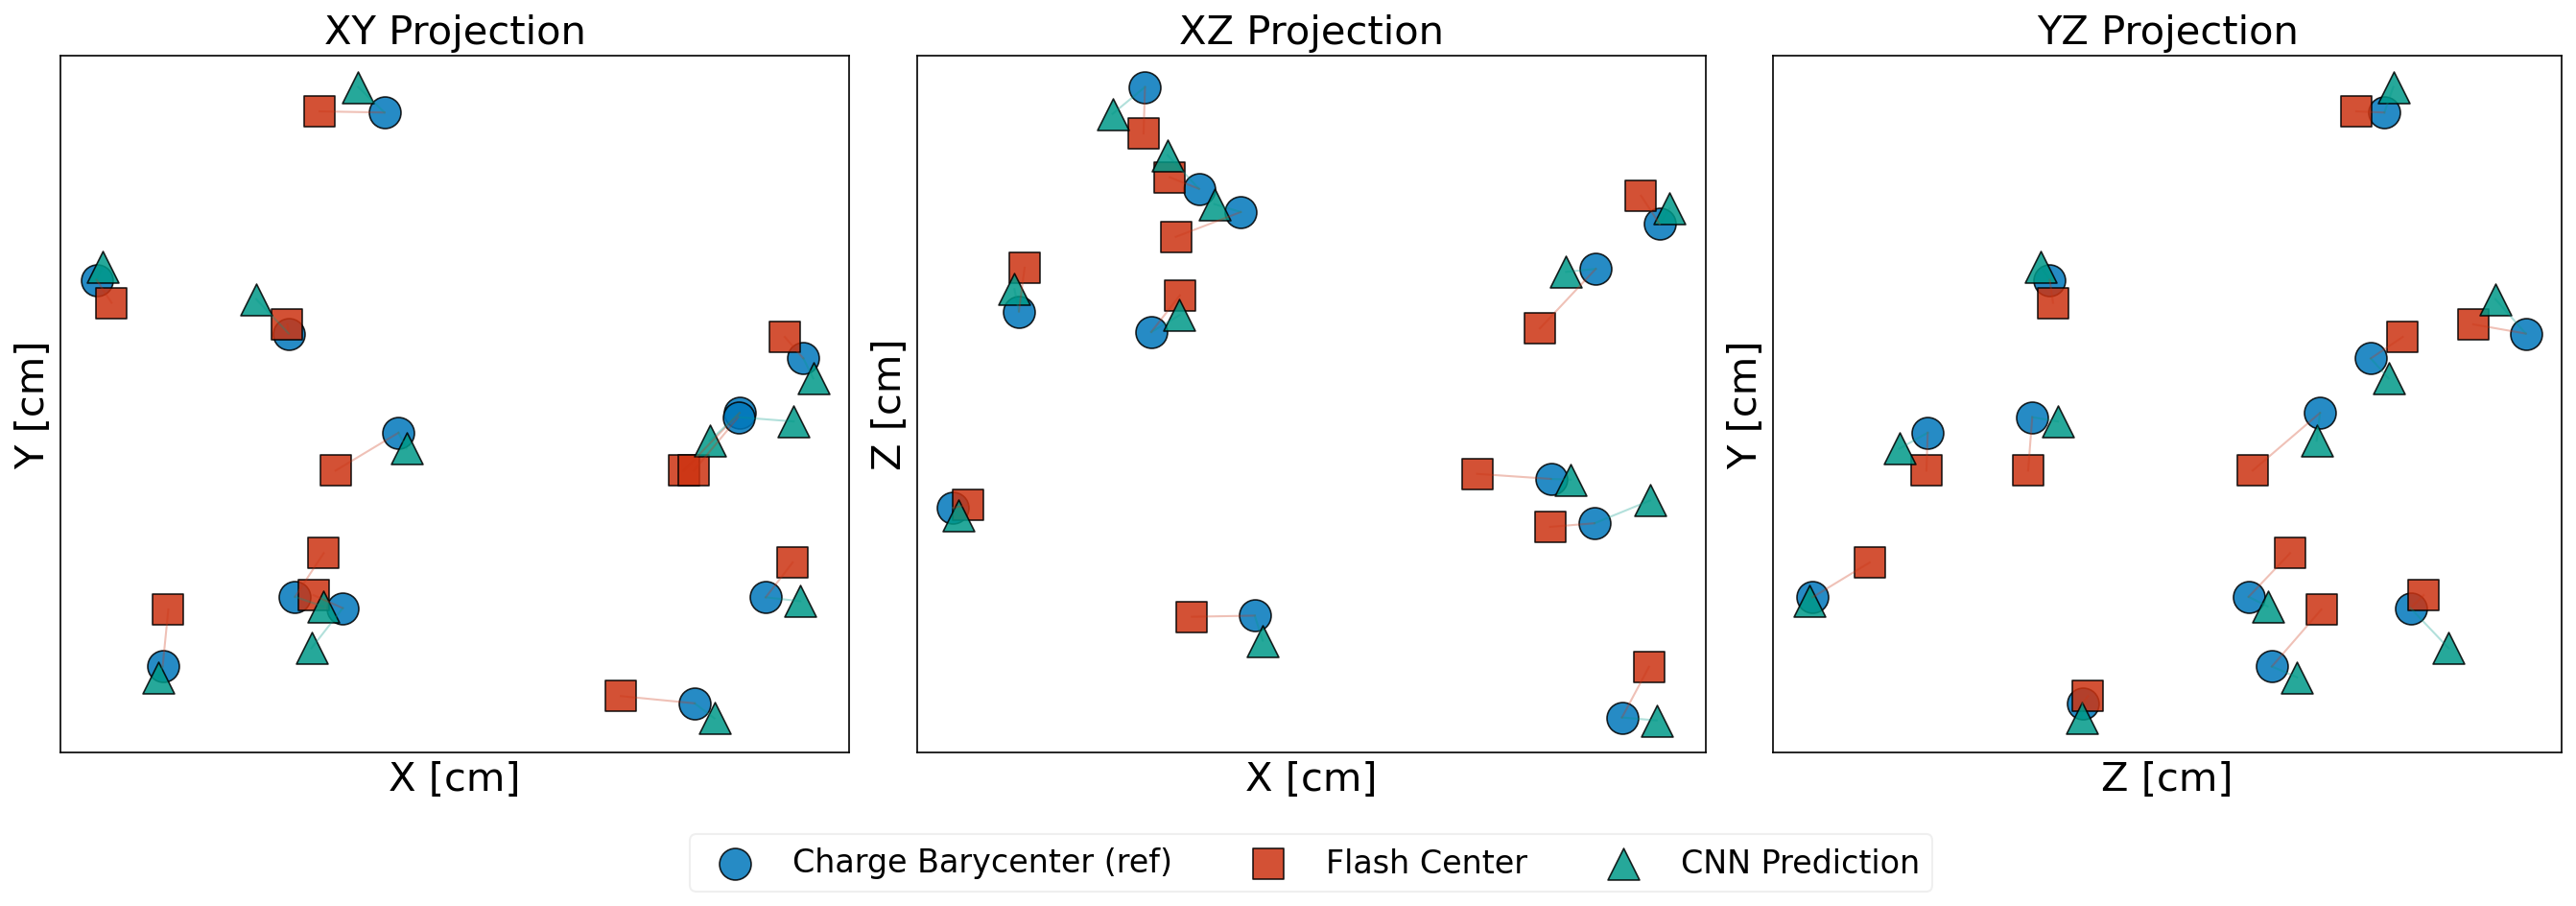

In [12]:
df_plot = df_valid.sample(n=12, random_state=120)

_fl = 20   # font label
_ft = 17   # font tick
_fs = 16   # font legend

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, row in df_plot.iterrows():
    for ax, (x0, x1, y0, y1) in zip(
        axes,
        [
            (row['chargeCenterX_abs'], row['flashCenterX_abs'], row['chargeCenterY'], row['flashCenterY']),
            (row['chargeCenterX_abs'], row['flashCenterX_abs'], row['chargeCenterZ'], row['flashCenterZ']),
            (row['chargeCenterZ'],       row['flashCenterZ'], row['chargeCenterY'], row['flashCenterY']),
        ]
    ):
        ax.plot([x0, x1], [y0, y1], '-', color=C_ALERT,    alpha=0.3, linewidth=1)

    for ax, (x0, x1, y0, y1) in zip(
        axes,
        [
            (row['chargeCenterX_abs'], row['pred_x'], row['chargeCenterY'], row['pred_y']),
            (row['chargeCenterX_abs'], row['pred_x'], row['chargeCenterZ'], row['pred_z']),
            (row['chargeCenterZ'],       row['pred_z'], row['chargeCenterY'], row['pred_y']),
        ]
    ):
        ax.plot([x0, x1], [y0, y1], '-', color=C_TERTIARY, alpha=0.3, linewidth=1)

proj_cfg = [
    ('chargeCenterX_abs', 'chargeCenterY', 'flashCenterX_abs', 'flashCenterY', 'pred_x', 'pred_y', 'X [cm]', 'Y [cm]', 'XY'),
    ('chargeCenterX_abs', 'chargeCenterZ', 'flashCenterX_abs', 'flashCenterZ', 'pred_x', 'pred_z', 'X [cm]', 'Z [cm]', 'XZ'),
    ('chargeCenterZ',       'chargeCenterY', 'flashCenterZ', 'flashCenterY', 'pred_z', 'pred_y', 'Z [cm]', 'Y [cm]', 'YZ'),
]

handles = None
for ax, (cx, cy, fx, fy, px, py, xl, yl, title) in zip(axes, proj_cfg):
    sc1 = ax.scatter(df_plot[cx], df_plot[cy], s=250, alpha=0.85, marker='o',
                     label='Charge Barycenter (ref)', color=C_PRIMARY,  edgecolors='black', linewidths=0.8)
    sc2 = ax.scatter(df_plot[fx], df_plot[fy], s=250, alpha=0.85, marker='s',
                     label='Flash Center',            color=C_ALERT,    edgecolors='black', linewidths=0.8)
    sc3 = ax.scatter(df_plot[px], df_plot[py], s=250, alpha=0.85, marker='^',
                     label='CNN Prediction',          color=C_TERTIARY, edgecolors='black', linewidths=0.8)
    if handles is None:
        handles = [sc1, sc2, sc3]
    ax.set_xlabel(xl, fontsize=_fl)
    ax.set_ylabel(yl, fontsize=_fl)
    ax.set_title(f'{title} Projection', fontsize=_fl, fontweight='normal')
    ax.tick_params(labelsize=_ft, which='both', length=4)
    ax.minorticks_off()
    ax.yaxis.set_ticklabels([])
    ax.yaxis.set_ticks([])
    ax.xaxis.set_ticklabels([])
    ax.xaxis.set_ticks([])

# Symmetric Y limits for panels with Y axis (XY and YZ)
for ax in [axes[0], axes[2]]:
    ylo, yhi = ax.get_ylim()
    ylim = max(abs(ylo), abs(yhi))
    ax.set_ylim(-ylim, ylim)

plt.tight_layout()

# Center the legend with the middle subplot (axes[1])
ax_mid = axes[1]
mid_pos = ax_mid.get_position()
legend_x = mid_pos.x0 + mid_pos.width / 2

fig.legend(handles=handles, fontsize=_fs, loc='lower center',
           bbox_to_anchor=(legend_x, -0.06), ncol=3, framealpha=0.2,
           bbox_transform=fig.transFigure)
plt.subplots_adjust(bottom=0.12)
fig.savefig(f"{FIG_DIR}/connections_plot.png", dpi=SAVE_DPI, bbox_inches='tight')
fig.savefig(f"{FIG_DIR}/connections_plot.pdf", bbox_inches='tight')
plt.show()

### 4.2 Position Bias — Gaussian Fit

Residual distributions for each coordinate.  
- **Row 1 — Charge − Flash:** measures the intrinsic BFM position offset relative to the charge barycenter.  
- **Row 2 — CNN − Charge:** measures the CNN prediction offset relative to the charge barycenter.

An iterative Gaussian fit (3 iterations of σ-clipping at 2.5σ) is performed on the core of each distribution. The fitted μ is the **bias** and σ is the **position resolution**. The 3D distance R = √(Δx² + Δy² + Δz²) is also computed for each comparison.

In [13]:
# Calculate differences between methods (using absolute value of X)
# Charge vs Flash
df_valid['diff_charge_flash_x'] = df_valid['chargeCenterX_abs'] - df_valid['flashCenterX_abs']
df_valid['diff_charge_flash_y'] = df_valid['chargeCenterY'] - df_valid['flashCenterY']
df_valid['diff_charge_flash_z'] = df_valid['chargeCenterZ'] - df_valid['flashCenterZ']

# CNN vs Charge
df_valid['diff_cnn_charge_x'] = df_valid['pred_x'] - df_valid['chargeCenterX_abs']
df_valid['diff_cnn_charge_y'] = df_valid['pred_y'] - df_valid['chargeCenterY']
df_valid['diff_cnn_charge_z'] = df_valid['pred_z'] - df_valid['chargeCenterZ']

/opt/conda/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 53291.
  res = hypotest_fun_out(*samples, **kwds)


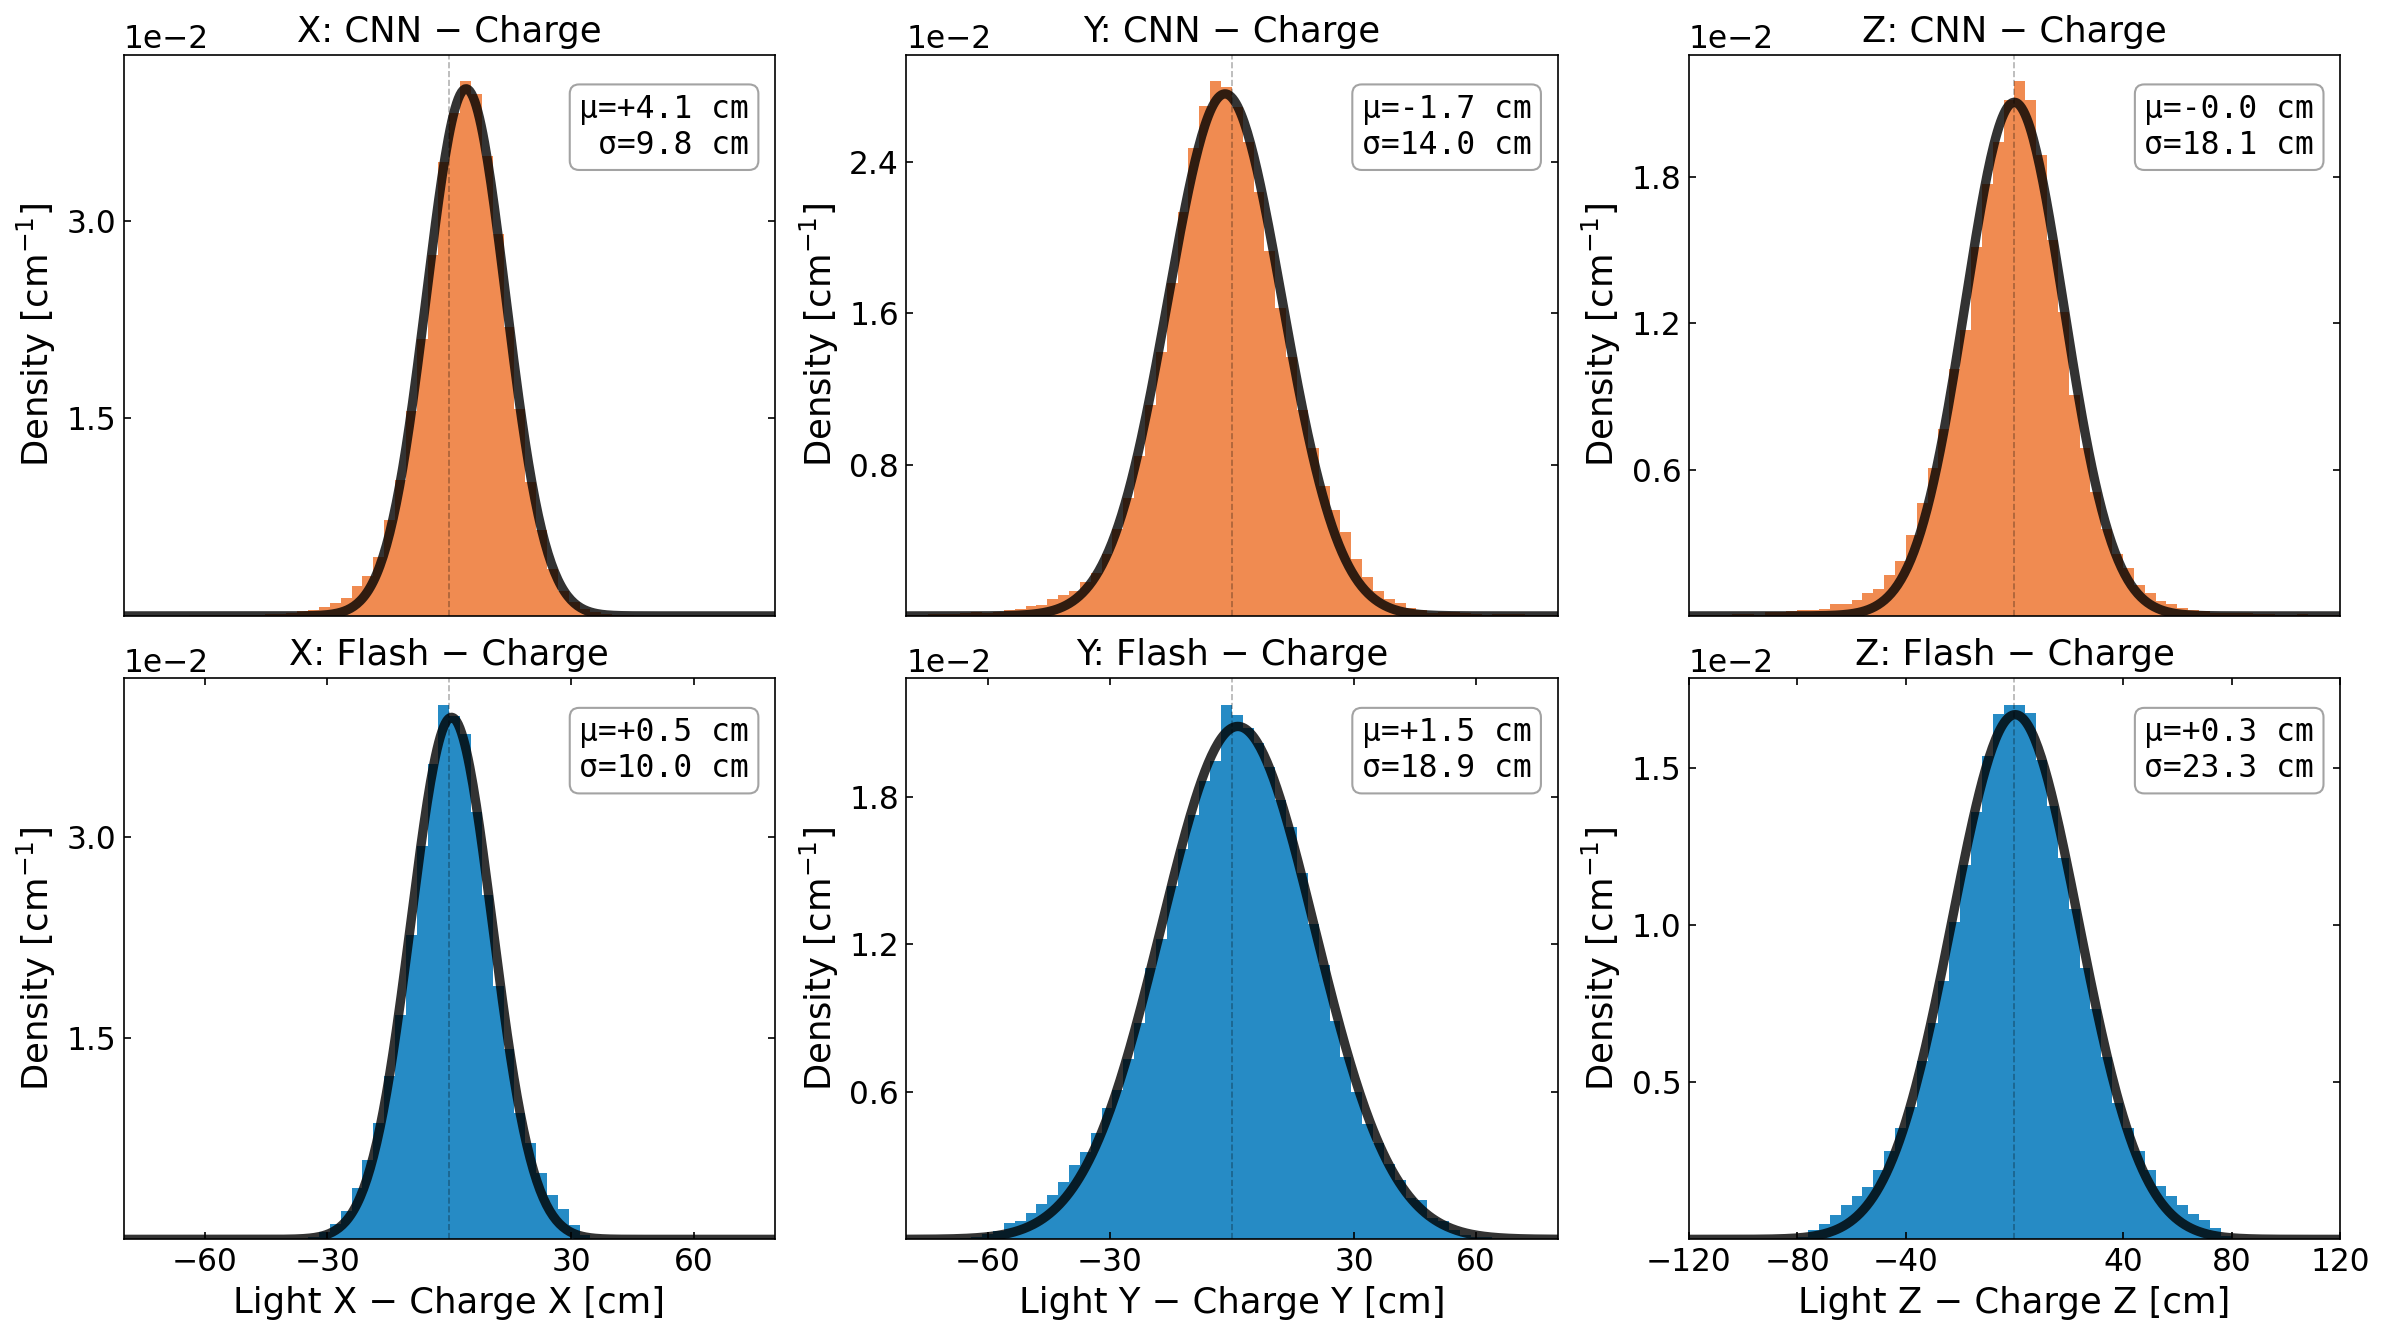

                              GAUSSIAN FIT RESULTS

Comparison                 Coord          Mean [cm]         Sigma [cm]
----------------------------------------------------------------------------------------------------
CNN − Charge                   X    4.10 +/-  0.10      9.75 +/-  0.10
CNN − Charge                   Y   -1.68 +/-  0.24     14.00 +/-  0.24
CNN − Charge                   Z   -0.04 +/-  0.38     18.14 +/-  0.38
----------------------------------------------------------------------------------------------------
Flash − Charge                 X    0.54 +/-  0.19     10.01 +/-  0.20
Flash − Charge                 Y    1.46 +/-  0.17     18.90 +/-  0.17
Flash − Charge                 Z    0.29 +/-  0.31     23.34 +/-  0.32
----------------------------------------------------------------------------------------------------

                    RESOLUTION SUMMARY + 3D DISTANCE (R)

Comparison                        sX         sY         sZ       Mean R     Median R
----

In [14]:
from matplotlib.ticker import AutoMinorLocator
import matplotlib.ticker as mticker

BIAS_ZOOM = 80    # cm
NBINS     = 60

_fl    = 17   # font labels
_ft    = 15   # font ticks
_fstat = 15   # font stat box
_ftit  = 17   # font title

def gaussian(x, A, mu, sigma):
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def fit_pos_residuals(diff, res_range=200, nbins=NBINS, n_sigma=2.5, n_iter=3):
    bins = np.linspace(-res_range, res_range, nbins + 1)
    cnt, edges = np.histogram(diff, bins=bins, density=True)
    cx = (edges[:-1] + edges[1:]) / 2
    peak = cnt.max()
    mu0  = cx[cnt.argmax()]
    above = cx[cnt >= peak / 2]
    sig0  = (above[-1] - above[0]) / 2.35 if len(above) > 1 else 20.0
    popt  = [peak, mu0, sig0]
    pcov  = None
    for _ in range(n_iter):
        mu_c, sig_c = popt[1], abs(popt[2])
        lo = max(mu_c - n_sigma * sig_c, -res_range)
        hi = min(mu_c + n_sigma * sig_c,  res_range)
        mask = (cx >= lo) & (cx <= hi) & (cnt > 0)
        if mask.sum() < 5:
            break
        try:
            popt, pcov = curve_fit(gaussian, cx[mask], cnt[mask], p0=popt,
                                   bounds=([0, -res_range, 0.1], [np.inf, res_range, res_range]),
                                   maxfev=10000)
        except Exception:
            break
    return popt, pcov

def fit_and_plot(ax, data, xlim, color, coord, title, fit_color='black', fit_lw=4.5, hatch=''):
    zoom = xlim[1]
    bins_z = np.linspace(-zoom, zoom, NBINS + 1)
    ax.hist(data, bins=bins_z, color=color, edgecolor='#6b3100' if hatch else 'none',
            density=True, alpha=0.85, hatch=hatch, linewidth=0)
    try:
        popt, pcov = fit_pos_residuals(data, res_range=zoom * 1.5)
        mu, sig = popt[1], abs(popt[2])
        perr = np.sqrt(np.diag(pcov)) if pcov is not None else [0, 0, 0]
        x_fit = np.linspace(-zoom, zoom, 400)
        ax.plot(x_fit, gaussian(x_fit, *popt), color=fit_color, alpha=0.8, lw=fit_lw)
        result = {'mean': mu, 'mean_err': perr[1], 'sigma': sig, 'sigma_err': perr[2],
                  **dict(zip(['shapiro_stat', 'shapiro_pvalue'], stats.shapiro(data)))}
    except Exception as e:
        print(f"Warning: Fit failed for {title} - {coord}: {e}")
        result = {'mean': data.mean(), 'mean_err': 0, 'sigma': data.std(),
                  'sigma_err': 0, 'shapiro_stat': 0, 'shapiro_pvalue': 0}

    ax.axvline(0, color='k', ls='--', alpha=0.3, lw=0.8)
    mu_val  = result["mean"]
    sig_val = result["sigma"]
    ax.text(0.96, 0.93, f'μ={mu_val:+.1f} cm\nσ={sig_val:.1f} cm',
            transform=ax.transAxes, fontsize=_fstat, va='top', ha='right',
            family='monospace', bbox=STAT_BOX)
    ax.set_xlim(-zoom, zoom)
    ax.set_xlabel(f'Δ{coord} = {title} [cm]', fontsize=_fl)
    ax.set_ylabel('Density [cm$^{-1}$]', fontsize=_fl)
    ax.set_title(f'{coord}: {title}', fontsize=_ftit, fontweight='normal')
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    ax.tick_params(labelsize=_ft)
    ax.minorticks_off()
    ax.grid(False)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(4, prune='lower'))
    ax.yaxis.get_offset_text().set_fontsize(_ft)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(6, prune=None))
    return result

coords = ['X', 'Y', 'Z']
xlim_fixed = {'X': (-80, 80), 'Y': (-80, 80), 'Z': (-120, 120)}
comparisons = {
    'CNN − Charge':   (['diff_cnn_charge_x',   'diff_cnn_charge_y',   'diff_cnn_charge_z'],   C_SECONDARY),
    'Flash − Charge': (['diff_charge_flash_x', 'diff_charge_flash_y', 'diff_charge_flash_z'], C_PRIMARY),
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fit_results = {}
for row_idx, (name, (cols, color)) in enumerate(comparisons.items()):
    for col_idx, (coord, col_name) in enumerate(zip(coords, cols)):
        fit_results[(name, coord)] = fit_and_plot(axes[row_idx, col_idx], df_valid[col_name].dropna(),
                                                   xlim_fixed[coord], color, coord, name)
# Remove zero from all x tick labels
for ax in axes.flat:
    lo, hi = ax.get_xlim()
    xt = [t for t in ax.get_xticks() if lo <= t <= hi and abs(t) > 0.1]
    ax.set_xticks(xt)

# Bottom row: custom xlabels
axes[1, 0].set_xlabel('Light X − Charge X [cm]', fontsize=_fl)
axes[1, 1].set_xlabel('Light Y − Charge Y [cm]', fontsize=_fl)
axes[1, 2].set_xlabel('Light Z − Charge Z [cm]', fontsize=_fl)
# Top row: remove xlabel and x ticks
for ax in axes[0]:
    ax.set_xlabel('')
    ax.xaxis.set_ticklabels([])
    ax.xaxis.set_ticks([])

plt.tight_layout()
fig.savefig(f"{FIG_DIR}/gaussian_fit_bias.png", dpi=SAVE_DPI, bbox_inches='tight')
fig.savefig(f"{FIG_DIR}/gaussian_fit_bias.pdf", bbox_inches='tight')
plt.show()

df_valid['R_charge_flash'] = np.sqrt(df_valid['diff_charge_flash_x']**2 +
                                      df_valid['diff_charge_flash_y']**2 +
                                      df_valid['diff_charge_flash_z']**2)
df_valid['R_cnn_charge'] = np.sqrt(df_valid['diff_cnn_charge_x']**2 +
                                    df_valid['diff_cnn_charge_y']**2 +
                                    df_valid['diff_cnn_charge_z']**2)

R_stats = {name: {'mean': df_valid[col].mean(), 'std': df_valid[col].std(), 'median': df_valid[col].median()}
           for name, col in [('Flash − Charge', 'R_charge_flash'), ('CNN − Charge', 'R_cnn_charge')]}

print("="*100 + "\n" + " "*30 + "GAUSSIAN FIT RESULTS\n" + "="*100)
print(f"\n{'Comparison':25s} {'Coord':>6s} {'Mean [cm]':>18s} {'Sigma [cm]':>18s}")
print("-"*100)
for name in comparisons:
    for coord in coords:
        r = fit_results[(name, coord)]
        print(f"{name:25s} {coord:>6s} {r['mean']:7.2f} +/- {r['mean_err']:5.2f}   {r['sigma']:7.2f} +/- {r['sigma_err']:5.2f}")
    print("-"*100)

print("\n" + "="*100 + "\n" + " "*20 + "RESOLUTION SUMMARY + 3D DISTANCE (R)\n" + "="*100)
print(f"\n{'Comparison':25s} {'sX':>10s} {'sY':>10s} {'sZ':>10s} {'Mean R':>12s} {'Median R':>12s}")
print("-"*100)
for name in comparisons:
    sigmas = [fit_results[(name, c)]['sigma'] for c in coords]
    print(f"{name:25s} {sigmas[0]:>10.2f} {sigmas[1]:>10.2f} {sigmas[2]:>10.2f} {R_stats[name]['mean']:>12.2f} {R_stats[name]['median']:>12.2f}")
print("="*100)

print("\n" + "="*100 + "\n" + " "*25 + "SHAPIRO-WILK NORMALITY TEST\n" + "="*100)
print("\nH0: Data comes from a normal distribution (p > 0.05 = Normal)\n")
print(f"\n{'Comparison':25s} {'Coord':>6s} {'Statistic':>12s} {'p-value':>12s} {'Normal?':>10s}")
print("-"*100)
for name in comparisons:
    for coord in coords:
        r = fit_results[(name, coord)]
        is_normal = "Yes" if r['shapiro_pvalue'] > 0.05 else "No"
        print(f"{name:25s} {coord:>6s} {r['shapiro_stat']:>12.4f} {r['shapiro_pvalue']:>12.4f} {is_normal:>10s}")
    print("-"*100)
print("="*100)

#### 4.2.1 Per-TPC Breakdown

Same Gaussian fit split by `selected_tpc` (0 = east, 1 = west) to check for TPC-dependent biases in the CNN model.

Total events: 53291
Events TPC 0: 30276 (56.8%)
Events TPC 1: 23015 (43.2%)


/opt/conda/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 30276.
  res = hypotest_fun_out(*samples, **kwds)
/opt/conda/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 23015.
  res = hypotest_fun_out(*samples, **kwds)


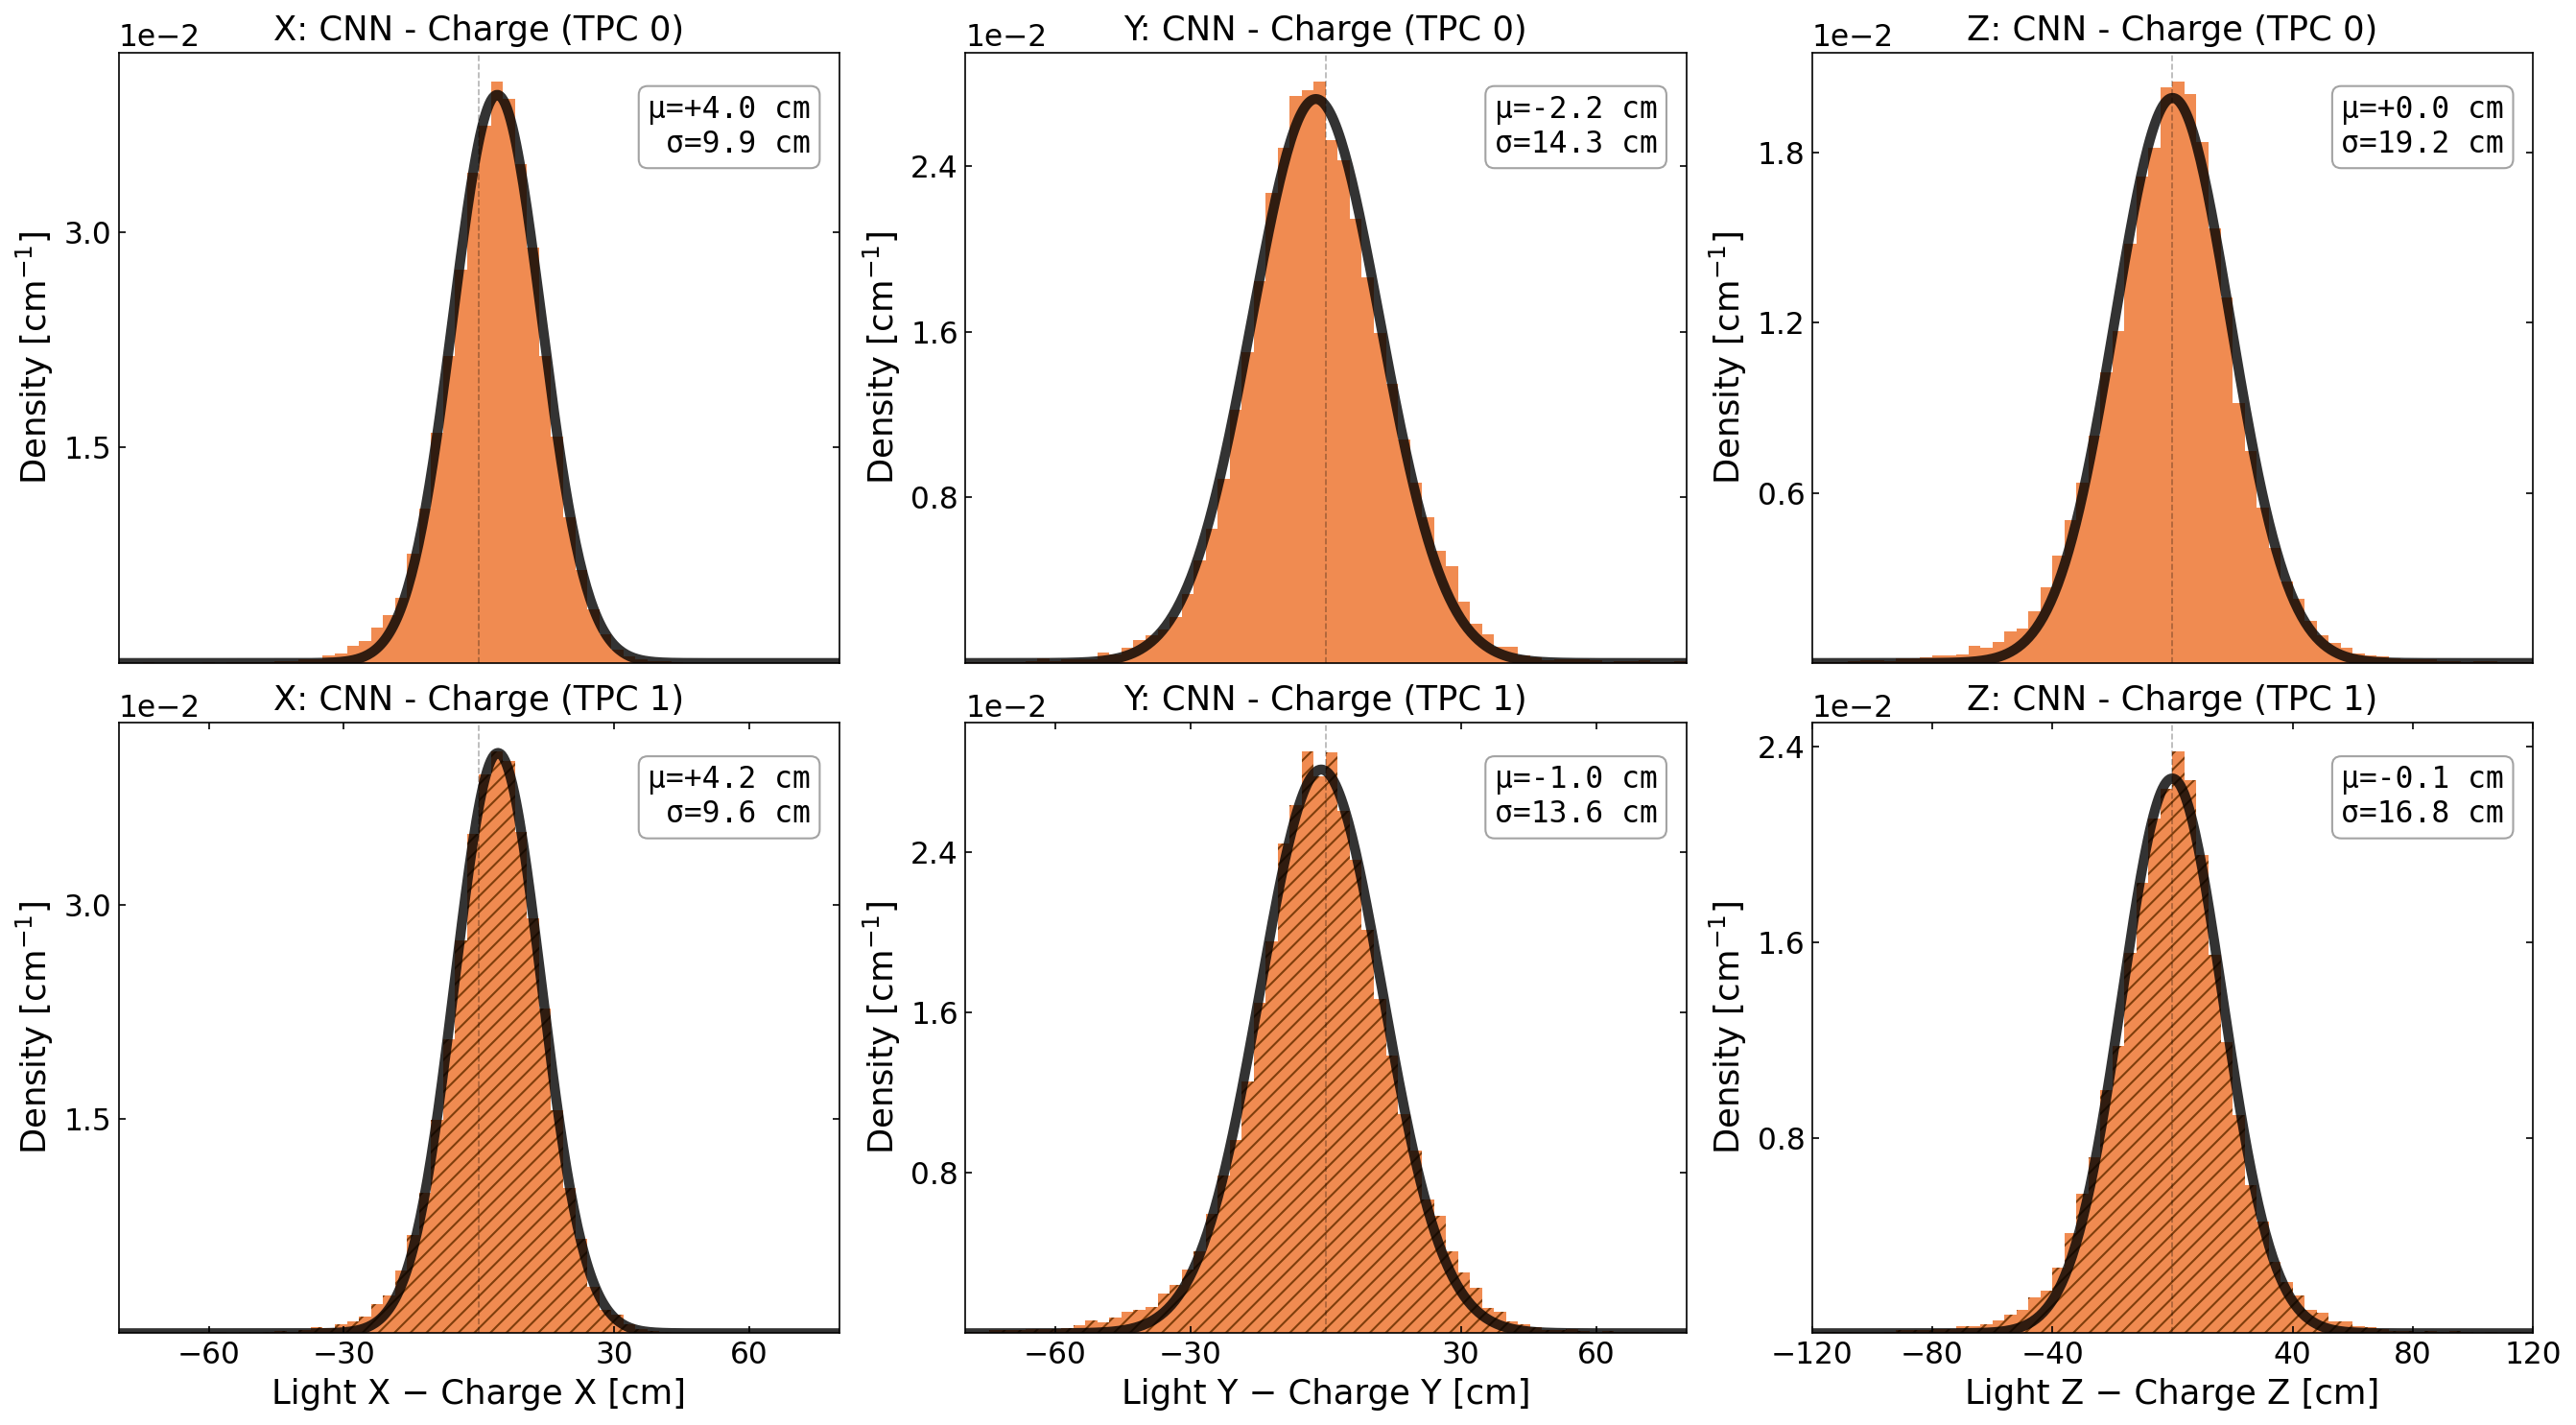


                              3D DISTANCE (R) BY TPC

TPC            Mean R [cm]      Std R [cm]   Median R [cm]        N events
----------------------------------------------------------------------------------------------------
TPC 0                26.69           19.49           22.85           30276
TPC 1                25.18           19.24           21.40           23015

                              GAUSSIAN FIT RESULTS BY TPC

TPC           Coord        Mean μ [cm]       Sigma σ [cm]     N events
----------------------------------------------------------------------------------------------------
TPC 0             X    4.03 ±  0.11    9.87 ±  0.11        30276
TPC 0             Y   -2.21 ±  0.29   14.26 ±  0.30        30276
TPC 0             Z    0.02 ±  0.38   19.24 ±  0.39        30276
----------------------------------------------------------------------------------------------------
TPC 1             X    4.19 ±  0.10    9.60 ±  0.10        23015
TPC 1             Y   -1.0

In [15]:
coords = ['X', 'Y', 'Z']
xlim_fixed = {'X': (-80, 80), 'Y': (-80, 80), 'Z': (-120, 120)}
diff_cols = ['diff_cnn_charge_x', 'diff_cnn_charge_y', 'diff_cnn_charge_z']

df_tpc0 = df_valid[df_valid['selected_tpc'] == 0].copy()
df_tpc1 = df_valid[df_valid['selected_tpc'] == 1].copy()
tpc_data = {0: (df_tpc0, C_SECONDARY), 1: (df_tpc1, C_SECONDARY)}

print(f"Total events: {len(df_valid)}")
print(f"Events TPC 0: {len(df_tpc0)} ({100*len(df_tpc0)/len(df_valid):.1f}%)")
print(f"Events TPC 1: {len(df_tpc1)} ({100*len(df_tpc1)/len(df_valid):.1f}%)")

hatch_map = {0: '', 1: '///'}
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fit_results_by_tpc = {}
for row_idx, (tpc, (df_tpc, color)) in enumerate(tpc_data.items()):
    for col_idx, (coord, diff_col) in enumerate(zip(coords, diff_cols)):
        result = fit_and_plot(axes[row_idx, col_idx], df_tpc[diff_col].dropna(),
                              xlim_fixed[coord], color, coord, f'CNN - Charge (TPC {tpc})',
                              fit_color='black', fit_lw=5, hatch=hatch_map[tpc])
        result['n_events'] = len(df_tpc)
        fit_results_by_tpc[(tpc, coord)] = result
# Remove zero from x ticks
for ax in axes.flat:
    lo, hi = ax.get_xlim()
    xt = [t for t in ax.get_xticks() if lo <= t <= hi and abs(t) > 0.1]
    ax.set_xticks(xt)
# Top row: remove xlabel and x ticks
for ax in axes[0]:
    ax.set_xlabel('')
    ax.xaxis.set_ticklabels([])
    ax.xaxis.set_ticks([])
# Bottom row: custom xlabels
axes[1, 0].set_xlabel('Light X − Charge X [cm]', fontsize=_fl)
axes[1, 1].set_xlabel('Light Y − Charge Y [cm]', fontsize=_fl)
axes[1, 2].set_xlabel('Light Z − Charge Z [cm]', fontsize=_fl)

for ax in axes.flat:
    ax.yaxis.get_offset_text().set_fontsize(_ft)

plt.tight_layout()
fig.savefig(f"{FIG_DIR}/gaussian_fit_bias_per_tpc.png", dpi=SAVE_DPI, bbox_inches='tight')
fig.savefig(f"{FIG_DIR}/gaussian_fit_bias_per_tpc.pdf", bbox_inches='tight')
plt.show()

for tpc, (df_tpc, _) in tpc_data.items():
    df_tpc['R_cnn_charge'] = np.sqrt(df_tpc['diff_cnn_charge_x']**2 +
                                      df_tpc['diff_cnn_charge_y']**2 +
                                      df_tpc['diff_cnn_charge_z']**2)

R_stats_tpc = {tpc: {'mean': tpc_data[tpc][0]['R_cnn_charge'].mean(),
                     'std': tpc_data[tpc][0]['R_cnn_charge'].std(),
                     'median': tpc_data[tpc][0]['R_cnn_charge'].median()}
               for tpc in [0, 1]}

print("\n" + "="*100 + "\n" + " "*30 + "3D DISTANCE (R) BY TPC\n" + "="*100)
print(f"\n{'TPC':10s} {'Mean R [cm]':>15s} {'Std R [cm]':>15s} {'Median R [cm]':>15s} {'N events':>15s}")
print("-"*100)
for tpc in [0, 1]:
    r = R_stats_tpc[tpc]
    print(f"{'TPC ' + str(tpc):10s} {r['mean']:>15.2f} {r['std']:>15.2f} {r['median']:>15.2f} {len(tpc_data[tpc][0]):>15d}")
print("="*100)

print("\n" + "="*100 + "\n" + " "*30 + "GAUSSIAN FIT RESULTS BY TPC\n" + "="*100)
print(f"\n{'TPC':10s} {'Coord':>8s} {'Mean μ [cm]':>18s} {'Sigma σ [cm]':>18s} {'N events':>12s}")
print("-"*100)
for tpc in [0, 1]:
    for coord in coords:
        r = fit_results_by_tpc[(tpc, coord)]
        print(f"{'TPC ' + str(tpc):10s} {coord:>8s} {r['mean']:7.2f} ± {r['mean_err']:5.2f} {r['sigma']:7.2f} ± {r['sigma_err']:5.2f} {r['n_events']:>12d}")
    print("-"*100)
print("="*100)

print("\n" + "="*100 + "\n" + " "*20 + "RESOLUTION SUMMARY (σ) + 3D DISTANCE (R) BY TPC\n" + "="*100)
print(f"\n{'TPC':10s} {'σ_X [cm]':>12s} {'σ_Y [cm]':>12s} {'σ_Z [cm]':>12s} {'Mean R [cm]':>15s} {'Median R [cm]':>15s}")
print("-"*100)
for tpc in [0, 1]:
    sigmas = [fit_results_by_tpc[(tpc, c)]['sigma'] for c in coords]
    print(f"{'TPC ' + str(tpc):10s} {sigmas[0]:>12.2f} {sigmas[1]:>12.2f} {sigmas[2]:>12.2f} {R_stats_tpc[tpc]['mean']:>15.2f} {R_stats_tpc[tpc]['median']:>15.2f}")
print("="*100)

print("\n" + "="*100 + "\n" + " "*25 + "SHAPIRO-WILK NORMALITY TEST BY TPC\n" + "="*100)
print("\nH0: Data comes from a normal distribution (p > 0.05 = Normal)\n")
print(f"{'TPC':10s} {'Coord':>8s} {'Statistic':>12s} {'p-value':>12s} {'Normal?':>10s}")
print("-"*100)
for tpc in [0, 1]:
    for coord in coords:
        r = fit_results_by_tpc[(tpc, coord)]
        is_normal = "Yes" if r['shapiro_pvalue'] > 0.05 else "No"
        print(f"{'TPC ' + str(tpc):10s} {coord:>8s} {r['shapiro_stat']:>12.4f} {r['shapiro_pvalue']:>12.4f} {is_normal:>10s}")
    print("-"*100)
print("="*100)

### 4.3 3D Distance Distribution

Overlay of the R = √(Δx² + Δy² + Δz²) distributions for both comparisons (Charge−Flash and CNN−Charge). Percentiles at P50, P68, P90, P95, P98 are reported as resolution metrics.

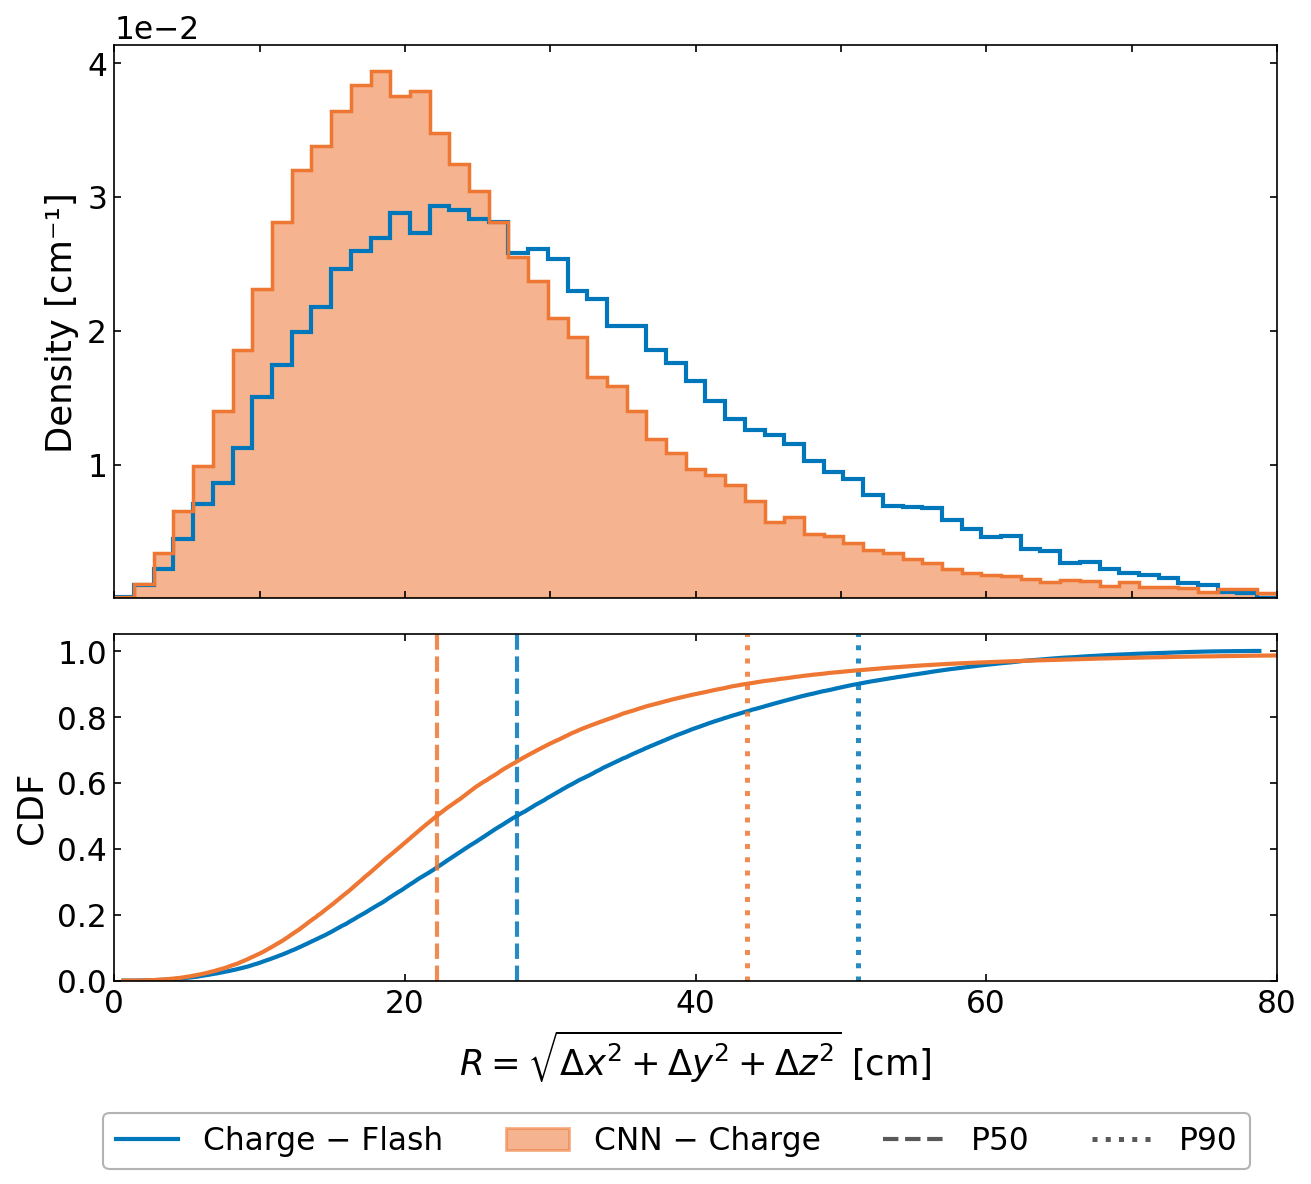

                    3D DISTANCE PERCENTILES (R)
Comparison                          P50 [cm]      P68 [cm]      P90 [cm]      P95 [cm]      P98 [cm]
----------------------------------------------------------------------------------------------------
Charge − Flash                         27.71         35.33         51.18         58.44         65.57
CNN − Charge                           22.20         28.31         43.52         53.59         70.62


In [16]:
_fl = 17; _ft = 15; _fs = 15
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

bins_common = np.linspace(0, 80, 60)
PERCENTILES = [50, 90]
P_STYLES    = [('--', 2.0), (':', 2.4)]

R_configs = [
    ('Charge − Flash', df_valid['R_charge_flash'], C_PRIMARY),
    ('CNN − Charge',   df_valid['R_cnn_charge'],   C_SECONDARY),
]

fig = plt.figure(figsize=(10, 8))
gs  = gridspec.GridSpec(2, 1, height_ratios=[1.6, 1], hspace=0.08)
ax_h = fig.add_subplot(gs[0])
ax_c = fig.add_subplot(gs[1])

handles_leg = []
for name, data, color in R_configs:
    filled = name.startswith('CNN')
    kw_hist = dict(bins=bins_common, density=True)
    if filled:
        ax_h.hist(data, histtype='stepfilled', color=color, alpha=0.55,
                  edgecolor=color, linewidth=1.6, **kw_hist)
        ax_h.hist(data, histtype='step', color=color, linewidth=1.6, **kw_hist)
        h = Patch(facecolor=color, alpha=0.55, edgecolor=color, linewidth=1.4, label=name)
    else:
        ax_h.hist(data, histtype='step', color=color, linewidth=2.0, **kw_hist)
        h = Line2D([0], [0], color=color, linewidth=2.0, label=name)
    handles_leg.append(h)

    xs = np.sort(data.dropna().values)
    ys = np.arange(1, len(xs) + 1) / len(xs)
    ax_c.plot(xs, ys, color=color, linewidth=2.0)
    for p, (ls, lw) in zip(PERCENTILES, P_STYLES):
        xp = np.percentile(xs, p)
        ax_c.axvline(xp, color=color, linestyle=ls, linewidth=lw, alpha=0.85)

for p, (ls, lw) in zip(PERCENTILES, P_STYLES):
    handles_leg.append(Line2D([0], [0], color='0.35', linestyle=ls, linewidth=lw,
                               label='P' + str(p)))

ax_h.set_ylabel('Density [cm⁻¹]', fontsize=_fl)
ax_h.yaxis.set_major_locator(mticker.MaxNLocator(5, prune='lower'))
ax_h.yaxis.get_offset_text().set_fontsize(_ft)
ax_h.tick_params(labelsize=_ft, which='both')
ax_h.minorticks_off()
ax_h.xaxis.set_ticklabels([])
ax_h.set_xlim(0, 80)
ax_h.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))

ax_c.set_xlabel(r'$R = \sqrt{\Delta x^2 + \Delta y^2 + \Delta z^2}$ [cm]', fontsize=_fl)
ax_c.set_ylabel('CDF', fontsize=_fl)
ax_c.set_ylim(0, 1.05)
ax_c.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
ax_c.tick_params(labelsize=_ft, which='both')
ax_c.minorticks_off()
ax_c.set_xlim(0, 80)
ax_c.xaxis.set_major_locator(mticker.MultipleLocator(20))

fig.legend(handles=handles_leg, fontsize=_fs, loc='lower center',
           bbox_to_anchor=(0.5, -0.07), ncol=len(handles_leg),
           framealpha=1.0, bbox_transform=fig.transFigure)
plt.subplots_adjust(bottom=0.10)

fig.savefig(f"{FIG_DIR}/3d_distance_distribution.png", dpi=SAVE_DPI, bbox_inches='tight')
fig.savefig(f"{FIG_DIR}/3d_distance_distribution.pdf", bbox_inches='tight')
plt.show()

hdr = '  '.join([f"{'Comparison':<30}", f"{'P50 [cm]':>12}", f"{'P68 [cm]':>12}",
                  f"{'P90 [cm]':>12}", f"{'P95 [cm]':>12}", f"{'P98 [cm]':>12}"])
print("=" * len(hdr))
print(" " * 20 + "3D DISTANCE PERCENTILES (R)")
print("=" * len(hdr))
print(hdr)
print("-" * len(hdr))
for name, data, _ in R_configs:
    p50  = data.median()
    p68  = np.percentile(data, 68)
    p90  = np.percentile(data, 90)
    p95  = np.percentile(data, 95)
    p98  = np.percentile(data, 98)
    row  = '  '.join([f"{name:<30}", f"{p50:>12.2f}", f"{p68:>12.2f}",
                       f"{p90:>12.2f}", f"{p95:>12.2f}", f"{p98:>12.2f}"])
    print(row)
print("=" * len(hdr))


## 5. Direction Comparison


> **Note:** A direct comparison — *CNN direction vs. charge PCA* — is not possible here because the charge PCA direction components are not saved in the `tpcpmtbarycentermatchingSCE` output tree. Only the pre-computed angle between light PCA and charge PCA is stored. Computing *CNN vs. charge PCA* would require saving the charge PCA direction vector in the matching module.  
> This calculation is already performed in `inference_highneutrinopurity_data.ipynb`, where both the charge PCA direction and the CNN prediction are available.